In [1]:
import os

for root, dirs, files in os.walk("/kaggle/input"):
    print("📁", root)
    for f in files:
        print("   📄", f)

📁 /kaggle/input
📁 /kaggle/input/datasets
📁 /kaggle/input/datasets/muhammadtaaha12
📁 /kaggle/input/datasets/muhammadtaaha12/cve-fix-rag
   📄 final_dataset.jsonl


In [2]:
# !pip install sentence-transformers faiss-cpu

In [3]:
import numpy as np 
import pandas as pd 
import sklearn 

## loading the dataset 

In [4]:
import json

data = []
with open("/kaggle/input/datasets/muhammadtaaha12/cve-fix-rag/final_dataset.jsonl") as f:
    for line in f:
        data.append(json.loads(line))

print("Loaded samples:", len(data))
print(data[0])  # sanity check

Loaded samples: 25321
{'vulnerable_code': 'project_loader: do not export empty environment\nmeta: do not export empty environment. Warn on empty environment.\n\nreturn \'{envvar}="${envvar}{separator}{paths}"\'.format(\nenvvar=envvar,\nseparator=separator,\npaths=combine_paths(paths, prepend, separator),\n)\nenv.append(\'export LD_LIBRARY_PATH="$SNAP_LIBRARY_PATH:$LD_LIBRARY_PATH"\')\n\'LD_LIBRARY_PATH="\' + ":".join(dependency_paths) + \':$LD_LIBRARY_PATH"\'\n+ ":".join(\n["{0}/usr/sbin", "{0}/usr/bin", "{0}/sbin", "{0}/bin", "$PATH"]\n).format(root)\n+ \'"\'\nexport PATH="$SNAP/usr/sbin:$SNAP/usr/bin:$SNAP/sbin:$SNAP/bin:$PATH"\nexport LD_LIBRARY_PATH="$SNAP_LIBRARY_PATH:$LD_LIBRARY_PATH"\nexport LD_LIBRARY_PATH="$SNAP_LIBRARY_PATH:$LD_LIBRARY_PATH"\nexport PATH="$SNAP/usr/sbin:$SNAP/usr/bin:$SNAP/sbin:$SNAP/bin:$PATH"\nexport LD_LIBRARY_PATH="$SNAP_LIBRARY_PATH:$LD_LIBRARY_PATH"\nexport PATH="$SNAP/usr/sbin:$SNAP/usr/bin:$SNAP/sbin:$SNAP/bin:$PATH"\nexport LD_LIBRARY_PATH="$SNAP_LIB

In [5]:
df = pd.DataFrame(data)

In [6]:
df

,vulnerable_code,fixed_code,file,language,pattern
0,project_loader: do not export empty environmen...,"combined_paths = combine_paths(paths, prepend,...",tests/unit/test_formatting_utils.py,python,general
1,"__drm_atomic_helper_crtc_reset(crtc, &cstate->...",if (cstate)\n__drm_atomic_helper_crtc_reset(cr...,drivers/gpu/drm/msm/disp/dpu1/dpu_crtc.c,c,general
2,"""THEIA_WEBVIEW_EXTERNAL_ENDPOINT"": ""${env:THEI...","""THEIA_WEBVIEW_EXTERNAL_ENDPOINT"": ""${env:THEI...",packages/plugin-ext/src/main/node/plugin-servi...,typescript,general
3,"var\tRemarkable = require('remarkable'),\npars...","var\tMarkdownIt = require('markdown-it'),\npar...",package.json,unknown,general
4,node.text if node\ncerts['signing'] << cert_no...,Utils.element_text(node)\ncerts['signing'] << ...,test/responses/response_node_text_attack.xml.b...,unknown,general
...,...,...,...,...,...
25316,\nFix mispelling of the environmental variable...,Bernhard Herzog (Intevation) discovered that t...,intelmq-manager/php/controller.php,php,general
25317,"N_(""unclosed quote"")\nint src, dst, count = 0,...","#define SPLIT_CMDLINE_ARGC_OVERFLOW 3\nN_(""unc...",alias.c,c,general
25318,if (eptr->numlines < line_idx)\n-,if (line_idx < 1 || line_idx > eptr->numlines)...,agent/mibgroup/agent/extend.c,c,general
25319,await utils.run(`git clone ${remoteUrl} ${_tmp...,const { runWithSpawn } = require('./run');\naw...,src/index.js,javascript,general


In [7]:
df.head()

,vulnerable_code,fixed_code,file,language,pattern
0,project_loader: do not export empty environmen...,"combined_paths = combine_paths(paths, prepend,...",tests/unit/test_formatting_utils.py,python,general
1,"__drm_atomic_helper_crtc_reset(crtc, &cstate->...",if (cstate)\n__drm_atomic_helper_crtc_reset(cr...,drivers/gpu/drm/msm/disp/dpu1/dpu_crtc.c,c,general
2,"""THEIA_WEBVIEW_EXTERNAL_ENDPOINT"": ""${env:THEI...","""THEIA_WEBVIEW_EXTERNAL_ENDPOINT"": ""${env:THEI...",packages/plugin-ext/src/main/node/plugin-servi...,typescript,general
3,"var\tRemarkable = require('remarkable'),\npars...","var\tMarkdownIt = require('markdown-it'),\npar...",package.json,unknown,general
4,node.text if node\ncerts['signing'] << cert_no...,Utils.element_text(node)\ncerts['signing'] << ...,test/responses/response_node_text_attack.xml.b...,unknown,general


In [8]:
import torch
print(torch.cuda.is_available())

True


## making the embeddings 

In [9]:
import torch
from sentence_transformers import SentenceTransformer

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"PyTorch sees CUDA: {torch.cuda.is_available()}")
print(f"GPU Name: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'N/A'}")
print(f"Model will run on: {device}")

model = SentenceTransformer("BAAI/bge-large-en-v1.5", device=device)
print(f"Model is on: {model.device}")

PyTorch sees CUDA: True
GPU Name: Tesla T4
Model will run on: cuda


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/52.0 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/191 [00:00<?, ?B/s]

Model is on: cuda:0


In [10]:
import torch
from sentence_transformers import SentenceTransformer

device = "cuda" if torch.cuda.is_available() else "cpu"

model = SentenceTransformer("BAAI/bge-large-en-v1.5", device=device)
texts = [
    d["vulnerable_code"] + "\n" + d["fixed_code"]
    for d in data[:2000]
]

print("Texts created:", len(texts))
print(texts[0])
embeddings = model.encode(
    texts,
    batch_size=128,   # increase for GPU
    show_progress_bar=True,
    convert_to_tensor=True,
    normalize_embeddings=True
)

embeddings = embeddings.cpu().numpy()

Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

BertModel LOAD REPORT from: BAAI/bge-large-en-v1.5
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Texts created: 2000
project_loader: do not export empty environment
meta: do not export empty environment. Warn on empty environment.

return '{envvar}="${envvar}{separator}{paths}"'.format(
envvar=envvar,
separator=separator,
paths=combine_paths(paths, prepend, separator),
)
env.append('export LD_LIBRARY_PATH="$SNAP_LIBRARY_PATH:$LD_LIBRARY_PATH"')
'LD_LIBRARY_PATH="' + ":".join(dependency_paths) + ':$LD_LIBRARY_PATH"'
+ ":".join(
["{0}/usr/sbin", "{0}/usr/bin", "{0}/sbin", "{0}/bin", "$PATH"]
).format(root)
+ '"'
export PATH="$SNAP/usr/sbin:$SNAP/usr/bin:$SNAP/sbin:$SNAP/bin:$PATH"
export LD_LIBRARY_PATH="$SNAP_LIBRARY_PATH:$LD_LIBRARY_PATH"
export LD_LIBRARY_PATH="$SNAP_LIBRARY_PATH:$LD_LIBRARY_PATH"
export PATH="$SNAP/usr/sbin:$SNAP/usr/bin:$SNAP/sbin:$SNAP/bin:$PATH"
export LD_LIBRARY_PATH="$SNAP_LIBRARY_PATH:$LD_LIBRARY_PATH"
export PATH="$SNAP/usr/sbin:$SNAP/usr/bin:$SNAP/sbin:$SNAP/bin:$PATH"
export LD_LIBRARY_PATH="$SNAP_LIBRARY_PATH:$LD_LIBRARY_PATH"
export PATH="$SNAP/usr/sb

Batches:   0%|          | 0/16 [00:00<?, ?it/s]

## the t-sne plot for checking the higher dimension

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/52.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/720 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/191 [00:00<?, ?B/s]

/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


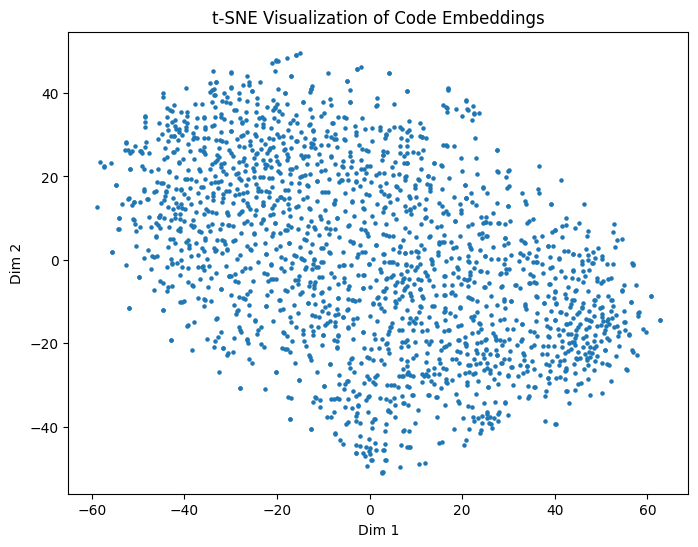

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from sentence_transformers import SentenceTransformer

model = SentenceTransformer("BAAI/bge-large-en")

# ⚠️ Always limit samples (VERY IMPORTANT)
X = np.array(embeddings[:2000])

# ✅ t-SNE works better after normalization
from sklearn.preprocessing import StandardScaler
X = StandardScaler().fit_transform(X)

# ✅ Run t-SNE
tsne = TSNE(
    n_components=2,
    perplexity=30,
    n_iter=1000,
    random_state=42,
    init="pca"
)

reduced = tsne.fit_transform(X)

# ✅ Plot
plt.figure(figsize=(8, 6))
plt.scatter(reduced[:, 0], reduced[:, 1], s=5)
plt.title("t-SNE Visualization of Code Embeddings")
plt.xlabel("Dim 1")
plt.ylabel("Dim 2")
plt.show()

In [12]:
# Number of samples you used for t‑SNE (2000)
n_samples = 2000

# Get the first n_samples patterns (labels)
labels = df["pattern"].iloc[:n_samples].values

In [13]:
unique_patterns = np.unique(labels)
pattern_to_num = {p: i for i, p in enumerate(unique_patterns)}
color_codes = np.array([pattern_to_num[p] for p in labels])

In [14]:
X = np.array(embeddings[:n_samples])   # shape (2000, embedding_dim)

/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


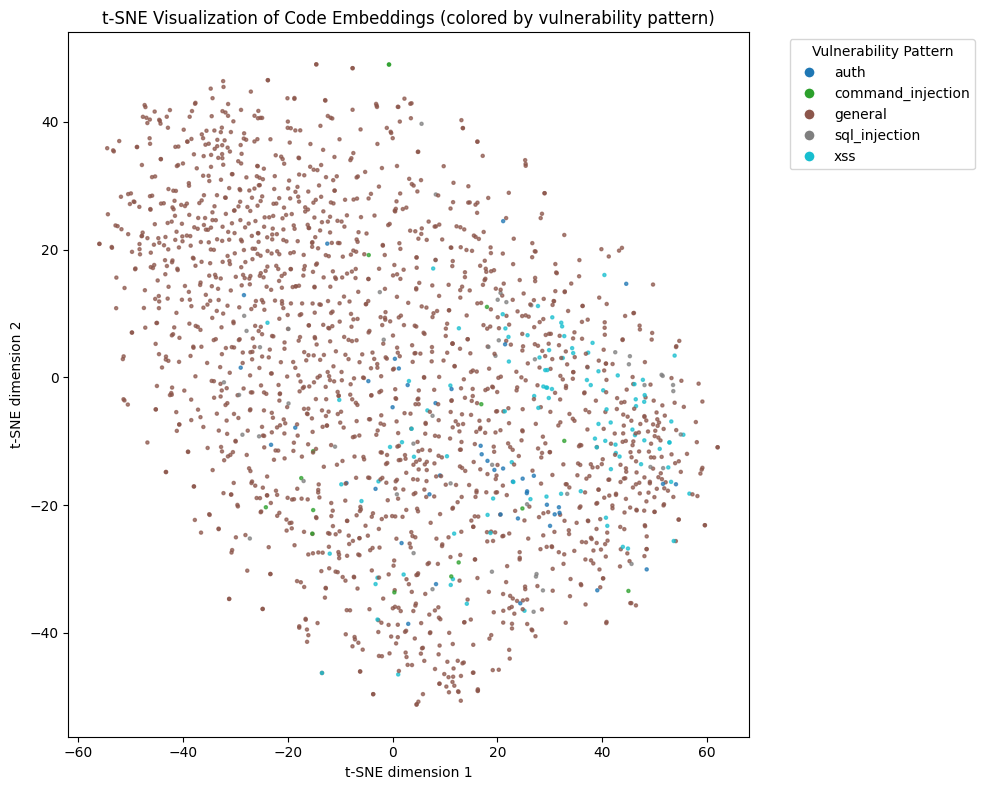

In [15]:
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

# t‑SNE (you already have this)
tsne = TSNE(n_components=2, perplexity=30, n_iter=1000, random_state=42, init="pca")
reduced = tsne.fit_transform(X)

# Create a figure
plt.figure(figsize=(10, 8))
sc = plt.scatter(reduced[:, 0], reduced[:, 1], c=color_codes, cmap='tab10', s=5, alpha=0.7)

# Add a legend
handles = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=sc.cmap(sc.norm(i)), markersize=8)
           for i in range(len(unique_patterns))]
plt.legend(handles, unique_patterns, title="Vulnerability Pattern", bbox_to_anchor=(1.05, 1), loc='upper left')

plt.title("t‑SNE Visualization of Code Embeddings (colored by vulnerability pattern)")
plt.xlabel("t‑SNE dimension 1")
plt.ylabel("t‑SNE dimension 2")
plt.tight_layout()
plt.show()

/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


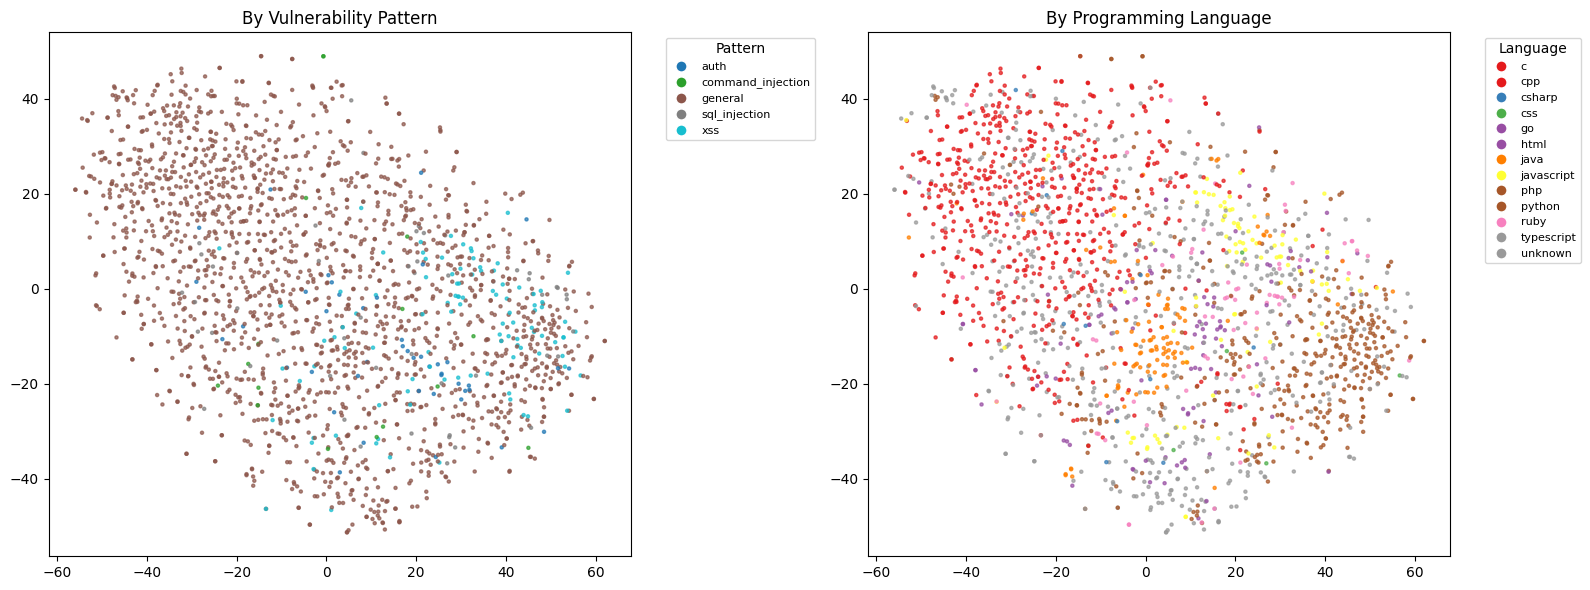

In [16]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler   # optional, but can keep

# -----------------------------------------------------------------
# 1. Prepare data (assuming df is your DataFrame and embeddings already computed)
# -----------------------------------------------------------------
n_samples = 2000   # must match the number of embeddings you use
X = np.array(embeddings[:n_samples])   # shape (2000, embedding_dim)

# (Optional) If you want to keep StandardScaler – but with normalized embeddings it's not necessary)
# X = StandardScaler().fit_transform(X)

# -----------------------------------------------------------------
# 2. Extract labels for the first n_samples
# -----------------------------------------------------------------
labels_pattern = df["pattern"].iloc[:n_samples].values
labels_language = df["language"].iloc[:n_samples].values

# -----------------------------------------------------------------
# 3. Convert to numeric codes for coloring
# -----------------------------------------------------------------
unique_patterns = np.unique(labels_pattern)
pattern_to_num = {p: i for i, p in enumerate(unique_patterns)}
color_codes_pattern = np.array([pattern_to_num[p] for p in labels_pattern])

unique_langs = np.unique(labels_language)
lang_to_num = {l: i for i, l in enumerate(unique_langs)}
color_codes_lang = np.array([lang_to_num[l] for l in labels_language])

# -----------------------------------------------------------------
# 4. Run t-SNE (once, reuse the same reduced coordinates for both plots)
# -----------------------------------------------------------------
tsne = TSNE(n_components=2, perplexity=30, n_iter=1000, random_state=42, init="pca")
reduced = tsne.fit_transform(X)

# -----------------------------------------------------------------
# 5. Create subplots
# -----------------------------------------------------------------
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# ---- Plot 1: colored by pattern ----
sc1 = ax1.scatter(reduced[:, 0], reduced[:, 1], c=color_codes_pattern, cmap='tab10', s=5, alpha=0.7)
ax1.set_title("By Vulnerability Pattern")
# Build legend handles for patterns
handles_pattern = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=sc1.cmap(sc1.norm(i)), markersize=8)
                   for i in range(len(unique_patterns))]
ax1.legend(handles_pattern, unique_patterns, title="Pattern", fontsize=8, bbox_to_anchor=(1.05, 1), loc='upper left')

# ---- Plot 2: colored by language ----
sc2 = ax2.scatter(reduced[:, 0], reduced[:, 1], c=color_codes_lang, cmap='Set1', s=5, alpha=0.7)
ax2.set_title("By Programming Language")
handles_lang = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=sc2.cmap(sc2.norm(i)), markersize=8)
                for i in range(len(unique_langs))]
ax2.legend(handles_lang, unique_langs, title="Language", fontsize=8, bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

## using the guess lang for controlling the hallucination for making the fix

In [17]:
# Cell 1: Install pygments (if not already installed)
!pip install -q pygments

In [ ]:
# Cell 2: Fill missing languages
import pandas as pd
from pygments.lexers import guess_lexer
from pygments.util import ClassNotFound
from tqdm import tqdm

# Make a copy or work on original df
df = df.copy()  # replace 'df' with your actual DataFrame variable name

def detect_language_from_code(code: str) -> str:
    """Return language name or 'unknown' if detection fails."""
    if not isinstance(code, str) or len(code.strip()) < 20:
        return 'unknown'
    try:
        lexer = guess_lexer(code)
        # Lexer name examples: 'Python', 'Java', 'C++', 'JavaScript'
        return lexer.name
    except ClassNotFound:
        return 'unknown'

# Apply only to rows where language is missing or 'unknown'
mask = (df['language'].isna()) | (df['language'].str.lower() == 'unknown')
rows_to_fix = df[mask]

print(f"Found {len(rows_to_fix)} rows with missing/unknown language. Detecting...")

# Try fixed_code first, then vulnerable_code
detected_langs = []
for idx, row in tqdm(rows_to_fix.iterrows(), total=len(rows_to_fix), desc="Detecting language"):
    code = row.get('fixed_code', '')
    if not isinstance(code, str) or len(code.strip()) < 20:
        code = row.get('vulnerable_code', '')
    lang = detect_language_from_code(code)
    detected_langs.append(lang)

# Assign back
df.loc[mask, 'language'] = detected_langs

# Show summary
print("\nLanguage distribution after fixing:")
print(df['language'].value_counts())
print(f"\nRemaining 'unknown': {(df['language'] == 'unknown').sum()}")

Found 6712 rows with missing/unknown language. Detecting...


Detecting language:  79%|███████▊  | 5282/6712 [30:58<02:21, 10.13it/s]  

## the sub plot after the fix 

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler   # optional, but can keep

# -----------------------------------------------------------------
# 1. Prepare data (assuming df is your DataFrame and embeddings already computed)
# -----------------------------------------------------------------
n_samples = 2000   # must match the number of embeddings you use
X = np.array(embeddings[:n_samples])   # shape (2000, embedding_dim)

# (Optional) If you want to keep StandardScaler – but with normalized embeddings it's not necessary)
# X = StandardScaler().fit_transform(X)

# -----------------------------------------------------------------
# 2. Extract labels for the first n_samples
# -----------------------------------------------------------------
labels_pattern = df["pattern"].iloc[:n_samples].values
labels_language = df["language"].iloc[:n_samples].values

# -----------------------------------------------------------------
# 3. Convert to numeric codes for coloring
# -----------------------------------------------------------------
unique_patterns = np.unique(labels_pattern)
pattern_to_num = {p: i for i, p in enumerate(unique_patterns)}
color_codes_pattern = np.array([pattern_to_num[p] for p in labels_pattern])

unique_langs = np.unique(labels_language)
lang_to_num = {l: i for i, l in enumerate(unique_langs)}
color_codes_lang = np.array([lang_to_num[l] for l in labels_language])

# -----------------------------------------------------------------
# 4. Run t-SNE (once, reuse the same reduced coordinates for both plots)
# -----------------------------------------------------------------
tsne = TSNE(n_components=2, perplexity=30, n_iter=1000, random_state=42, init="pca")
reduced = tsne.fit_transform(X)

# -----------------------------------------------------------------
# 5. Create subplots
# -----------------------------------------------------------------
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# ---- Plot 1: colored by pattern ----
sc1 = ax1.scatter(reduced[:, 0], reduced[:, 1], c=color_codes_pattern, cmap='tab10', s=5, alpha=0.7)
ax1.set_title("By Vulnerability Pattern")
# Build legend handles for patterns
handles_pattern = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=sc1.cmap(sc1.norm(i)), markersize=8)
                   for i in range(len(unique_patterns))]
ax1.legend(handles_pattern, unique_patterns, title="Pattern", fontsize=8, bbox_to_anchor=(1.05, 1), loc='upper left')

# ---- Plot 2: colored by language ----
sc2 = ax2.scatter(reduced[:, 0], reduced[:, 1], c=color_codes_lang, cmap='Set1', s=5, alpha=0.7)
ax2.set_title("By Programming Language")
handles_lang = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=sc2.cmap(sc2.norm(i)), markersize=8)
                for i in range(len(unique_langs))]
ax2.legend(handles_lang, unique_langs, title="Language", fontsize=8, bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

## making the fix for the unclassified vernulbilities 

## using the pre-tuned code bert model for making the labels of the embeddings 

In [ ]:
import torch
from transformers import AutoTokenizer, AutoModel
import pandas as pd
from tqdm import tqdm

# Load model (once)
tokenizer = AutoTokenizer.from_pretrained("microsoft/graphcodebert-base")
model = AutoModel.from_pretrained("mahdin70/GraphCodeBERT-VulnCWE", trust_remote_code=True)
model.eval()

# Define your mapping from CWE to your category (example)
cwe_to_category = {
    89: "injection",      # SQLi
    77: "injection",      # Command injection
    79: "xss",
    287: "auth",
    306: "auth",
    22: "file",
    502: "deserialization",
    # ... add more as you see predictions
}

def classify_code_to_category(code: str) -> str:
    inputs = tokenizer(code, return_tensors="pt", truncation=True, max_length=512)
    with torch.no_grad():
        outputs = model(**inputs)
    # Output structure: outputs["vul_logits"], outputs["cwe_logits"]
    vuln_prob = torch.softmax(outputs["vul_logits"], dim=-1)[0][1].item()
    if vuln_prob < 0.5:
        return "misc"   # not vulnerable? but you expect vulnerable code
    cwe_id = outputs["cwe_logits"].argmax(dim=-1).item()
    return cwe_to_category.get(cwe_id, "misc")

# Apply to rows where pattern == "general"
mask = df["pattern"] == "general"
df.loc[mask, "pattern"] = df.loc[mask, "fixed_code"].apply(classify_code_to_category)